In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from math import radians, cos, sin, asin, sqrt
import math
from itertools import combinations


In [2]:
df = pd.read_csv("df_assignment.csv.gz")


focus_crime = [
    "larceny theft",
    "motor vehicle theft",
    "robbery",
    "assault",
    "drug offense",
    "weapons offense",
    "vandalism",
    "suicide",
]

# remapping "malicious mischief" to "vandalism"
df.loc[df["category"] == "malicious mischief", "category"] = "vandalism"

# 1.1 Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

Draws from: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

Using your combined dataset (2003–present), plot the total number of incidents per year for each of your Personal Focus Crimes. Display at least the years 2003–2025.
Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

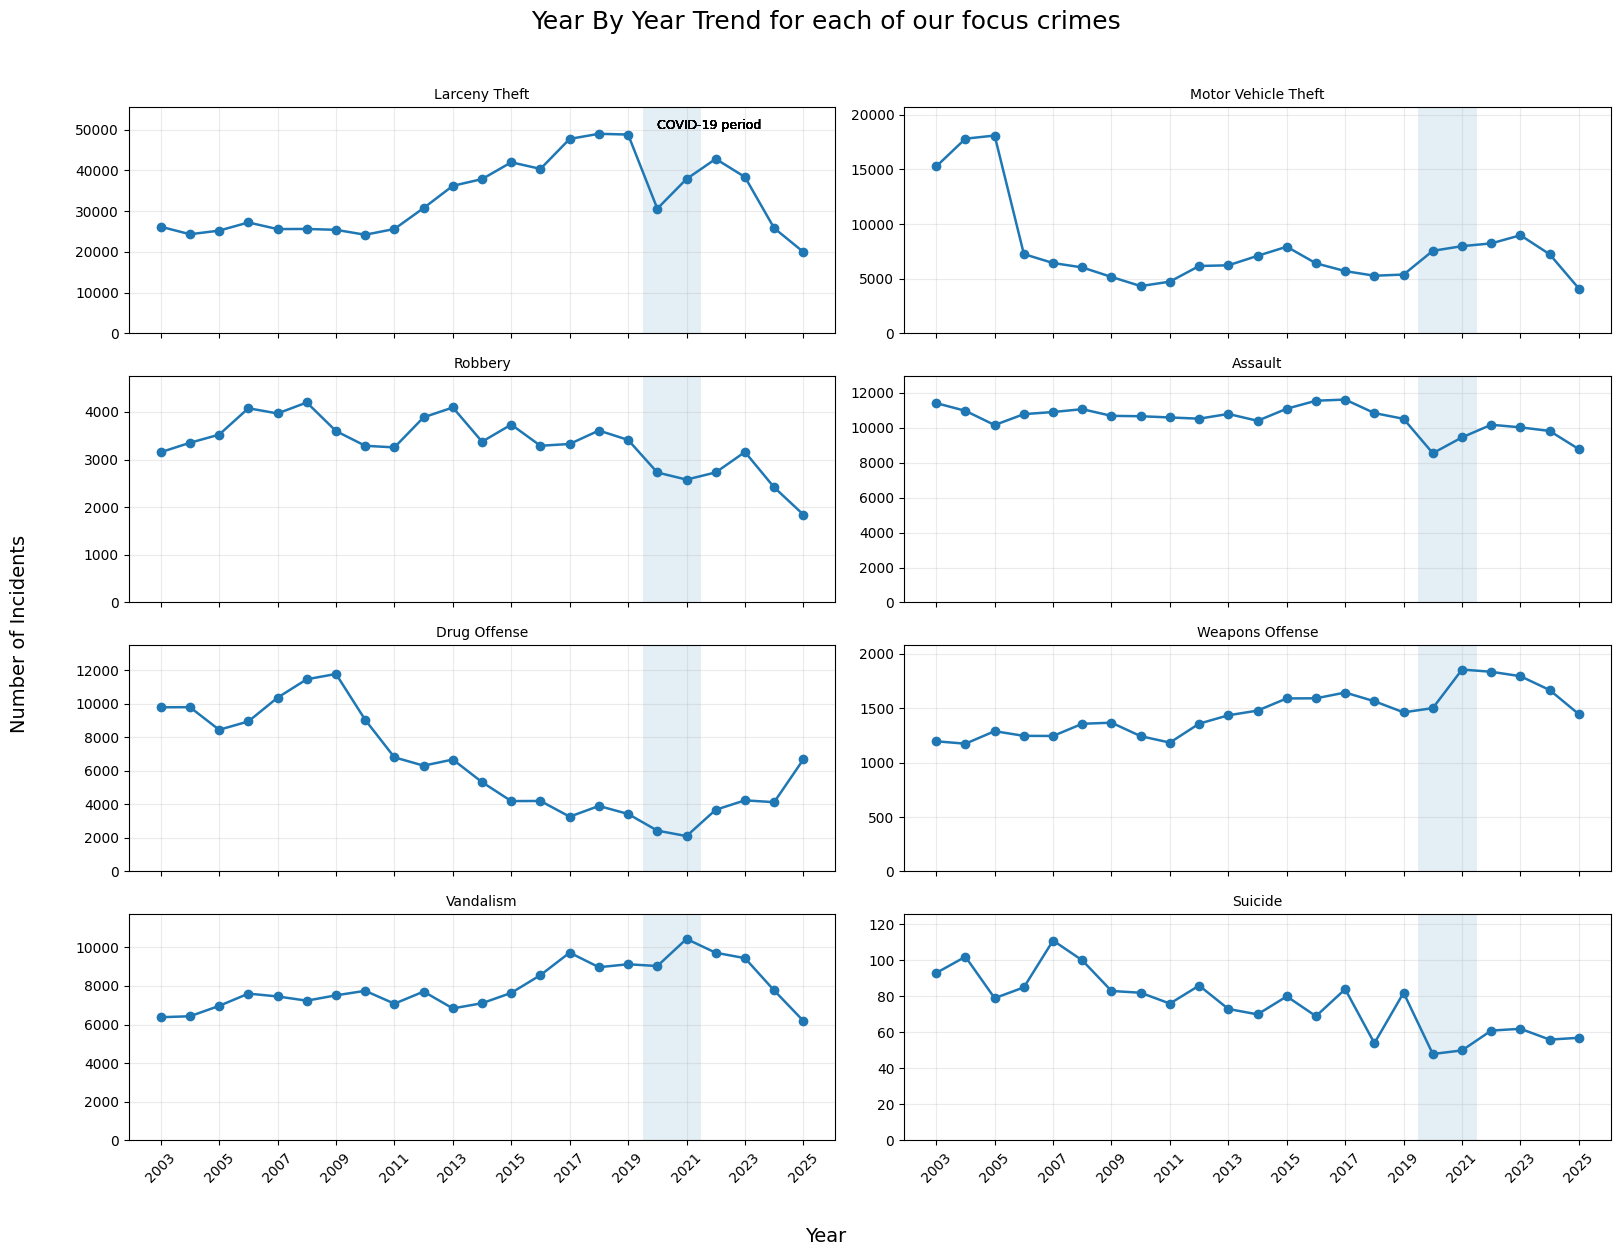

In [3]:

counts = (
    df[df["category"].isin(focus_crime)]
    .groupby(["year", "category"])
    .size()
    .unstack("category", fill_value=0)
    .sort_index()
)

years_to_label = [2003, 2005, 2007, 2009, 2011, 2013, 2015, 2017, 2019 , 2021, 2023, 2025]

fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)


axes = np.array(axes).reshape(4, 2)

for idx, crime in enumerate(focus_crime):
    r, c = divmod(idx, 2)
    ax = axes[r, c]

    y = counts.get(crime, 0)

    ax.plot(counts.index, y.values, marker="o", linewidth=1.8)
    ax.set_title(crime.title(), fontsize=10)
    ax.grid(True, alpha=0.25)

    ax.axvspan(2019.5, 2021.5, alpha=0.12)
    axes[0, 0].text(
        2020, 0.95, "COVID-19 period",
        transform=axes[0, 0].get_xaxis_transform(),
        fontsize=9, va="top"
    )

    ax.set_xticks(years_to_label)
    ax.tick_params(axis="x", rotation=45)

    ax.set_ylim(bottom=0, ymax=ax.get_ylim()[1] * 1.1)

for j in range(len(focus_crime), axes.size):
    axes.flat[j].set_visible(False)

fig.supxlabel("Year" , fontsize=14, y=-0.01)
fig.supylabel("Number of Incidents", fontsize=14, x=-0.01)
fig.suptitle("Year By Year Trend for each of our focus crimes",y=1.02, fontsize=18)

plt.tight_layout()
plt.show()


The above plot show the evolutuion of each of our chosen focus crimes from 2003 to 2025. We can see that there is no significant overall trend that spans clearly across all the different types of crime. However, there are some different tendencies for different categories. It is for example interesting to look at what effect Covid-19 had on crime in San Francisco. From the plot we can see that some types of crime such as larceny/theft and assault had a drastic reduction from 2019 to 2020 indicating an effect from covid-19. This also makes logically sense in a way that if fewer people are less outside on the street or at bars in the evening,, then the chance of assault or theft is also likely to drop. 

Another interesting trend that might also be Covid related is that we can see that drug offense was on a steady decline from 2009 to 2021, but when the world moved out of covid isolation this trend seems to have turned and it has been increasing every since. This could be Covid related, but it could also be due to other factors, as it is also not clear to us why drug offense started to decline like this in the first place.

The last interesting thing we see in the plot is that there is a significant drop in motor vehicle theft from 2005 to 2006 according to our data this type of crime got less that halved during this period. The most likely explanation to this is that it is not actually reflecting a chance in the real world but a change in how they report motor vehicle theft. This highlights an important lesson in data analysis. datasets can contain structural breaks or inconsistencies, and apparent trends should be interpreted cautiously rather than taken at face value.

# 1.2 Crime Profiles by Police District

For each police district, compute the conditional crime profile for the selected crimes using

$$
r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}
$$

Values above 1 indicate the crime is **over-represented** in that district relative to the city average, while values below 1 indicate it is **under-represented**.

Visualize the ratios (e.g., with a heatmap or bar chart) and identify one district whose crime profile stands out, explaining possible reasons for the pattern.

In [4]:
# Filter to focus crimes only
df_focus = df[df["category"].isin(focus_crime)].copy()

# Dropping rows if any missing district info present
df_focus = df_focus.dropna(subset=["police_district"])

# Count crimes per district per category
counts = (
    df_focus.groupby(["police_district", "category"])
    .size()
    .unstack("category", fill_value=0)
)

for crime in focus_crime:
    if crime not in counts.columns:
        counts[crime] = 0

counts = counts[focus_crime]  # Reordering columns to match focus_crime order
# print(counts.shape)

**Computing the ratio according to the given formula**

In [5]:
district_totals = counts.sum(axis=1)  # Total crimes per district
profile = counts.div(district_totals, axis=0)  # P(crime | district)

# computing P(crime)
city_totals = counts.sum(axis=0)  # Total of each crime city-wide
grand_total = city_totals.sum()  # Grand total of all focus crimes
city_profile = city_totals / grand_total  # P(crime)

# computing the ratio
ratio_table = profile.div(city_profile, axis=1)

**Showing the ratios using heatmap**

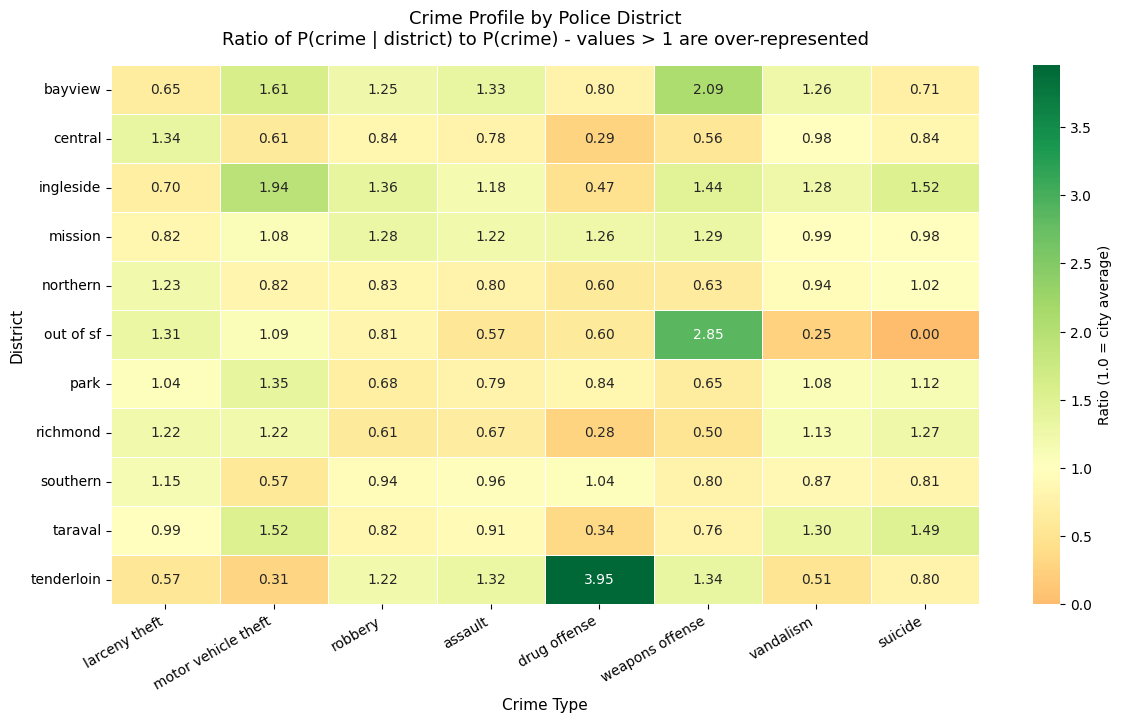

In [6]:
# showing in the  heatmap
fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    ratio_table,
    cmap="RdYlGn",
    center=1.0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Ratio (1.0 = city average)"},
)

ax.set_title(
    "Crime Profile by Police District\n"
    "Ratio of P(crime | district) to P(crime) - values > 1 are over-represented",
    fontsize=13,
    pad=15,
)
ax.set_xlabel("Crime Type", fontsize=11)
ax.set_ylabel("District", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.show()

**Analysis from the heatmap:**

The most noticeable crime-profile in the San Francisco District Crime Ratio is in the Tenderloin District. As shown in the heat map, the drug offense ratio in the Tenderloin is 3.95, which is approximately four times higher than the San Francisco city-wide average for Drug Offenses, and the darkest cell on the heat map for all eleven districts and eight selected crime types. No other district/crime type combination has a higher ratio compared to the Tenderloin District. On the other hand, there are very few districts/crimes that have a lower ratio than those related to the theft of vehicles and residential targeting, with the lowest being 0.31 and 0.51, respectively, across all eight crime categories in the city.

The data from [ABC7 News (2022)](https://abc7news.com/post/sf-tenderloin-drug-arrests-narcan-homeless/11535735/) also shows that approximately 85% of all drug-related arrests in San Francisco occur in the Tenderloin district. In addition, the city has traditionally located addiction treatment centers, homeless shelters, and social service agencies within the Tenderloin district. Based on the information provided by this study, it is likely that the concentration of these services in the Tenderloin district may be one of the reasons why we found the ratio of drug offenses in the Tenderloin was almost four times greater than the city-wide average across 8 crime categories.

In contrast, the Tenderloin is an incredibly densely populated and relatively small 50-block neighborhood in downtown San Francisco. This area is known as one of the most walkable neighborhoods in the city and the most transit-rich area in San Francisco. Additionally, only 11% of households in certain portions of the Tenderloin own a car, and approximately 85% of all the homes in the Tenderloin have no vehicles ([SF Chronicle, 2025](https://www.sfchronicle.com/sf/article/car-ownership-by-neighborhood-20050210.php), [WalkSF (2018)](https://walksf.org/2018/02/02/designing-a-safer-taylor-street/). Therefore, obviously, there are fewer vehicles available for thieves to steal. This evidence supports our finding of an extremely low motor vehicle theft ratio of 0.31 in Tenderloin.

In summary, the high rate of drug offenses in the Tenderloin (3.95) isn't just a result of things that individuals choose to do; it is also a product of decades of policy decisions to concentrate social services, poverty, and at-risk populations in a very small geographic area. The increased police presence results in more arrests being recorded in this area. Combined with heavy policing, this creates a feedback loop, more arrests justify more police, which produces more arrests that increase the potential for bias. This is the exact type of bias that poses a threat to predictive policing tools. The data is based on where the police are looking, rather than where crime actually is.

# 1.3 Visualizing Distributions

This exercise explores the distribution of crime data using several visualization techniques.

- Create a **jitter plot** of incident times for one selected crime to examine how timestamps are recorded.
- Generate a **QQ plot** for the latitude distribution of two crimes and compare it to a normal distribution.
- Use **box plots** to visualize the time-of-day distribution of the selected crimes and identify patterns (e.g., daytime vs nighttime activity).

In [7]:
# convert datetime column to proper datetime format
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df = df.dropna(subset=["datetime"])

# extract time information
df["hour"] = df["datetime"].dt.hour
df["minute"] = df["datetime"].dt.minute
df["weekday"] = df["datetime"].dt.weekday

df_focus = df[df["category"].isin(focus_crime)].copy()

### 1.3A Jitter plot

Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the  x-axis and add vertical jitter.

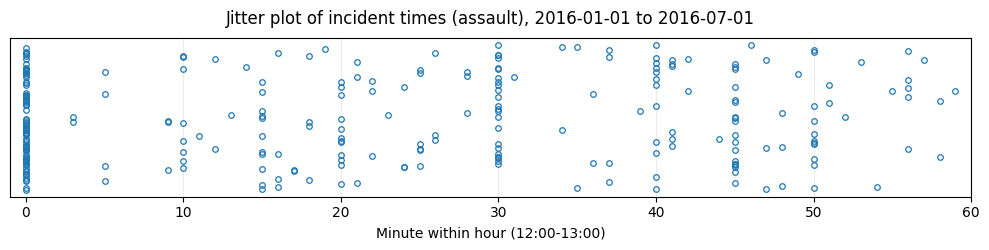

In [8]:
crime = "assault"
start = "2016-01-01"
end   = "2016-07-01"
target_hour = 12

sub = df_focus[
    (df_focus["category"] == crime) &
    (df_focus["datetime"] >= start) &
    (df_focus["datetime"] < end) &
    (df_focus["hour"] == target_hour)
].copy()

minutes = sub["minute"].dropna().to_numpy()

# vertical jitter
y = np.random.uniform(-0.12, 0.12, size=len(minutes))

plt.figure(figsize=(10, 2.6))
plt.plot(minutes, y, "o", markersize=4, markerfacecolor="none", markeredgewidth=0.9)

plt.xlim(-1, 60)
plt.xlabel(f"Minute within hour ({target_hour:02d}:00-{(target_hour+1)%24:02d}:00)")
plt.yticks([])
plt.title(f"Jitter plot of incident times ({crime}), {start} to {end}", pad=10)

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

The jitter plot shows the distribution of assault incidents from the hours 12:00-13:00. Each point represents an incident and is sorted by the minute on the x-axis. A small vertical jitter is added so that overlapping points can be seen more clearly.

The plot shows heavy clustering at certain minutes, especially at the start of the hour and around other popular rounded minute values (10,15,20,30,40,45,50). This suggests that incident times in the dataset are not always recorded with exact precision. Instead, they are rounded or estimated to convenient times which are easily remembered.

This pattern indicates that the time information in the dataset may have a limited precision. Rather than representing the exact minute an incident occurrs, the recorded times may be approximated or rounded estimates which were entered by officers.

### 1.3B Probability Plot (QQ Plot)

Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (scipy.stats.probplot is your friend here.)

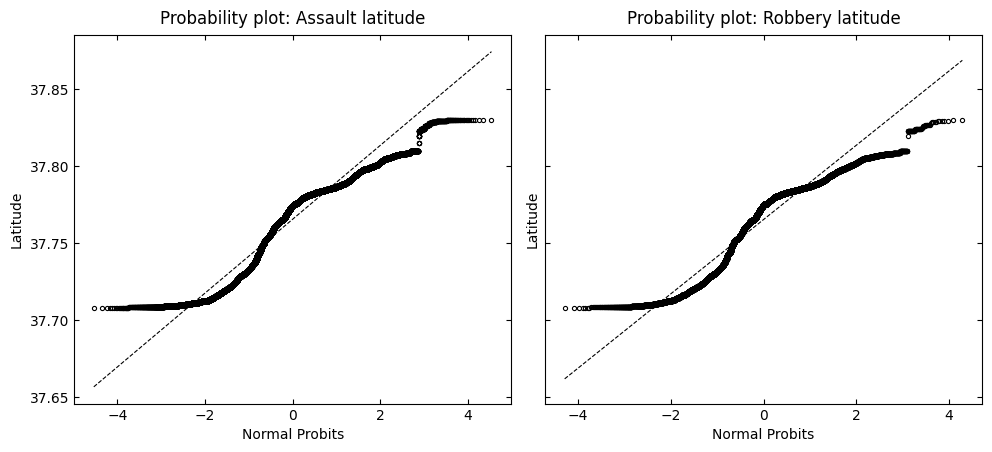

In [9]:
crime1 = "assault"
crime2 = "robbery"

geo = df[
    df["latitude"].between(37.0, 38.5) &
    df["longitude"].between(-123.0, -121.5)
].copy()

lat1 = geo.loc[geo["category"] == crime1, "latitude"].dropna().to_numpy()
lat2 = geo.loc[geo["category"] == crime2, "latitude"].dropna().to_numpy()

def probability_plot(ax, data, title):
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm", fit=True)

    ax.plot(osm, osr, "o", ms=3, mfc="none", mec="k", mew=0.8)
    xline = np.array([osm.min(), osm.max()])
    ax.plot(xline, intercept + slope * xline, "k--", lw=0.8)

    ax.set_title(title, pad=8)
    ax.set_xlabel("Normal Probits")
    ax.set_ylabel("Latitude")
    ax.tick_params(direction="in", top=True, right=True)

fig, ax = plt.subplots(1, 2, figsize=(10, 4.6), sharey=True)

probability_plot(ax[0], lat1, "Probability plot: Assault latitude")
probability_plot(ax[1], lat2, "Probability plot: Robbery latitude")

plt.tight_layout(pad=1.0)
plt.show()

The probability plots compare the observed latitude values to a normal (Gaussian) distribution.

If all points followed the straight line exactly, it would mean that the latitude values are normally distributed.
This would mean that the spatial distribution of crimes along the latitude of the city follows a bell-shaped pattern.

In both plots, the points deviate from the straight line in the lower and upper tails, creating an S-shaped curve.
The middle of the distribution follows the line more closely than the rest.

The deviation from the normal distribution suggests that the crime locations are not evenly distributed across the city's latitude.
Instead, the incidents tend to cluster in specific areas of the city, likely in neighborhoods with higher crime levels.
Since San Francisco has geographic boundaries and concentrated areas of crime, the spatial distribution of the incidents does not follow a perfect normal distribution.

### 1.3C Box plots of time-of-day

For each of your Personal Focus Crimes, extract the time-of-day of every incident.
Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.

C:\Users\victo\AppData\Local\Temp\ipykernel_17752\1181878263.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


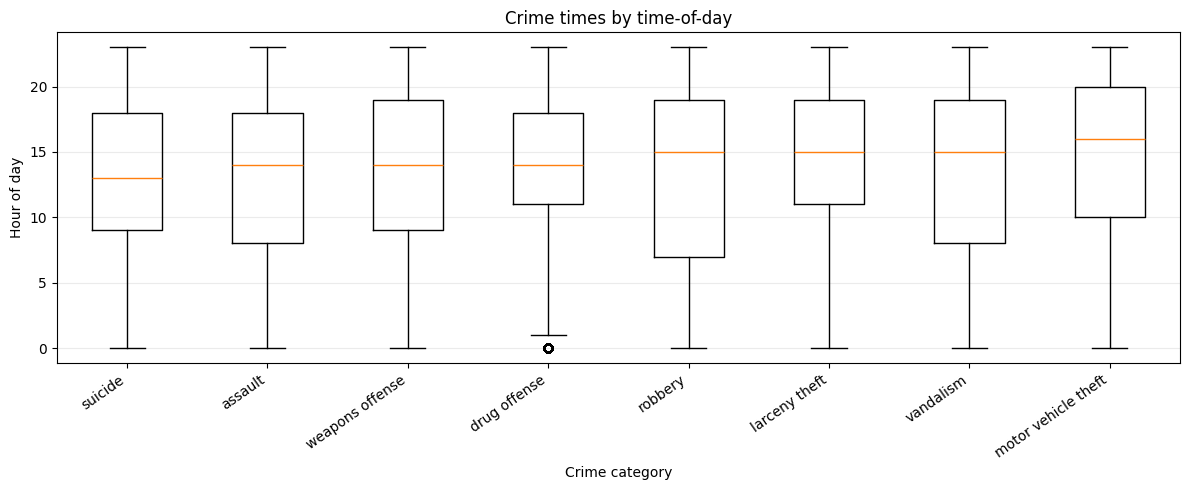

In [10]:
# The order is based on the median (ascending order)
order = (
    df_focus.groupby("category")["hour"]
    .median()
    .sort_values()
    .index
)

data = [
    df_focus.loc[df_focus["category"] == crime, "hour"].dropna()
    for crime in order
]

plt.figure(figsize=(12,5))

plt.boxplot(
    data,
    labels=order,
    showfliers=True
)

plt.xticks(rotation=35, ha="right")

plt.xlabel("Crime category")
plt.ylabel("Hour of day")
plt.title("Crime times by time-of-day")

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

The box plots show how the time-of-day distribution differs between the crime categories. Most of the crimes have median times in the afternoon or early evening, around 14:00–16:00. They have been sorted by the median in ascending order to allow for better analysis. Some crimes, such as motor vehicle theft and vandalism, appear to occur slightly later in the day, while others like assault and suicide have earlier median times. However, the interquartile ranges of all the crimes are fairly wide, which suggests that the crimes occur throughout the day rather than being restricted to a narrow timeframe.

A limitation of the box plot that time-of-day is a circular variable. The hours of the day go from 23:00 back to 00:00, but the box plot treats time as a linear scale from 0 to 23. This means that incidents that happen close to midnight can appear far apart in the plot even though they actually happen close to each other. For example, crimes that occur at 23:50 and 00:10 are only twenty minutes apart but would appear on opposite ends of the scale. This means that the box plot doesn't handle the wrap-around at midnight and this slightly distorts the interpretation of crimes that peak late at night.

# 1.4 Spatial Power Law

This exercise examines whether crime is evenly distributed across San Francisco or concentrated in hotspots.

- Divide the city into ~100m × 100m grid cells using latitude and longitude.
- Count incidents of the most common focus crime in each cell.
- Compute how many cells contain \(k\) incidents ( \(N(k)\) ).
- Plot \((k+1)\) vs \(N(k)\) on **linear** and **log–log** axes.
- Use the log–log plot to evaluate whether the spatial distribution follows a **power-law** and discuss what this implies about crime hotspots.

* Step 1: Divide San Francisco into a grid of approximately 
 cells using latitude and longitude. It is fine to ignore that the Earth isn't flat — the approximation is good enough for this purpose.

In [11]:
# theft data
theft_data = df[df["category"] == "larceny theft"]

lon = pd.to_numeric(theft_data["longitude"], errors="coerce")
lat = pd.to_numeric(theft_data["latitude"], errors="coerce")

mask = (
    (lon > -123.0) & (lon < -122.) &
    (lat > 37.0)   & (lat < 38.18)
)

lon = lon[mask].to_numpy()
lat = lat[mask].to_numpy()


def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    # convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles
    return c * r

# after some testing we found that 0.2 km is a good bin size for our grid
bin_size_km = 0.2  

lon_min, lon_max = lon.min(), lon.max()
lat_min, lat_max = lat.min(), lat.max()

height_km = haversine(lon_min, lat_min, lon_min, lat_max)

width_km_bottom = haversine(lon_min, lat_min, lon_max, lat_min)
width_km_top    = haversine(lon_min, lat_max, lon_max, lat_max)
width_km = 0.5 * (width_km_bottom + width_km_top)

n_lat_bins = int(np.ceil(height_km / bin_size_km))
n_lon_bins = int(np.ceil(width_km  / bin_size_km))

print( "amount_lon_bins:", n_lon_bins, "amount_lat_bins:", n_lat_bins)

total_cells = n_lon_bins * n_lat_bins
print("total cells:", total_cells)

amount_lon_bins: 66 amount_lat_bins: 68
total cells: 4488


* Step 2: Count the number of incidents of your chosen crime in each grid cell (use all years of data).

* Step 3: Tally the distribution. Count how many cells have exactly 
 incidents — call this 
 — for 
 up to the maximum.


In [12]:
counts, lon_edges, lat_edges = np.histogram2d(
    lon, lat,
    bins=[n_lon_bins, n_lat_bins],
    range=[[lon_min, lon_max], [lat_min, lat_max]]
)

cell_counts = counts.flatten().astype(int)

# counting how many cells have k counts
nk = np.bincount(cell_counts)
k_vals = np.arange(len(nk))

print("Amount of empty cells:", nk[0])

Amount of empty cells: 1894


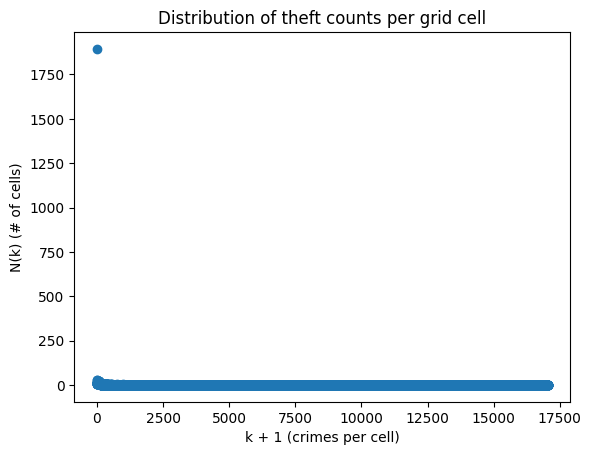

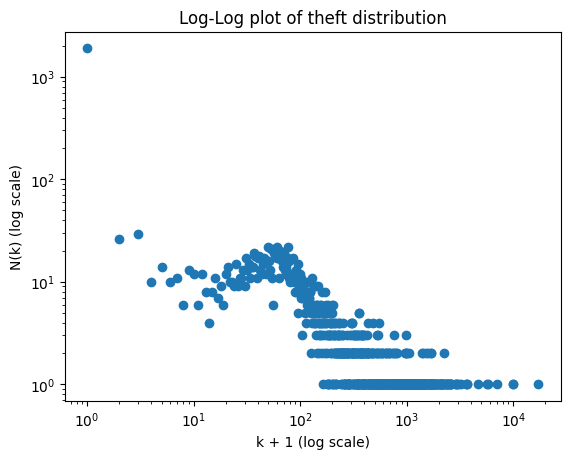

In [13]:
plt.figure()
plt.plot(k_vals + 1, nk, marker="o", linestyle="none")
plt.xlabel("k + 1 (crimes per cell)")
plt.ylabel("N(k) (# of cells)")
plt.title("Distribution of theft counts per grid cell")
plt.show()

plt.figure()
plt.loglog(k_vals + 1, nk, marker="o", linestyle="none")
plt.xlabel("k + 1 (log scale)")
plt.ylabel("N(k) (log scale)")
plt.title("Log-Log plot of theft distribution")
plt.show()

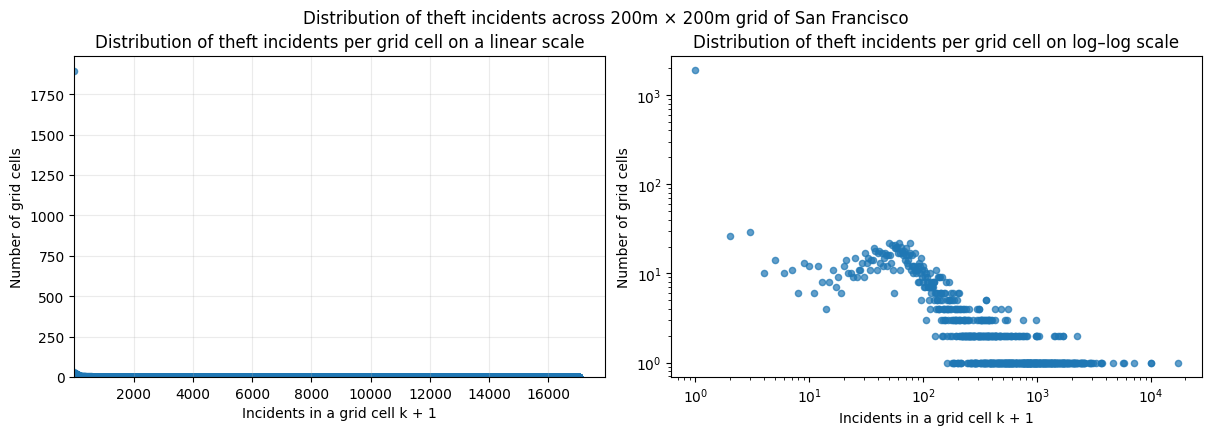

In [14]:
x = k_vals + 1
y = nk

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Linear plot
ax = axes[0]
ax.scatter(x, y, s=20, alpha=0.7)
ax.set_title("Distribution of theft incidents per grid cell on a linear scale")
ax.set_xlabel("Incidents in a grid cell k + 1")
ax.set_ylabel("Number of grid cells")
ax.grid(True, alpha=0.25)


ax.set_ylim(bottom=0)
ax.set_xlim(left=1)


# Log-log plot
ax = axes[1]

mask = y > 0
ax.scatter(x[mask], y[mask], s=20, alpha=0.7)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Distribution of theft incidents per grid cell on log–log scale")
ax.set_xlabel("Incidents in a grid cell k + 1")
ax.set_ylabel("Number of grid cells")


fig.suptitle(
    "Distribution of theft incidents across 200m × 200m grid of San Francisco",
    y=1.05
)

plt.show()

The linear plot clearly show why sometimes you need a log-log plot to reveal trends within data, as we can cleary see that more than half of the cells have 0 incidents of theft and the rest are spread so thin that it is not visibly possible to see if there is any numerical difference between the values.

When we examine the log–log plot, we do not see a single straight line across the full range, which we would expect if the distribution followed a perfect power law. Instead, we observe a very large number of cells with only a few incidents and a small number of cells with very high incident counts, while relatively few cells fall in the mid-range. This indicates a heavy-tailed distribution, where crime is highly concentrated in a limited number of hotspots.

This pattern makes sense in a real-world context. Most areas of San Francisco are residential or low-activity zones where theft incidents are rare, while a small number of locations such as downtown areas, commercial districts, and transit hubs attract large crowds and therefore present more opportunities for theft. As a result, crime is not evenly distributed across space but is instead clustered in specific high-activity areas. This helps explain why we see many low-count cells, a few extreme hotspots, and fewer cells with moderate levels of crime. We have also plotted a heatmat plot to investigate this a bit further.

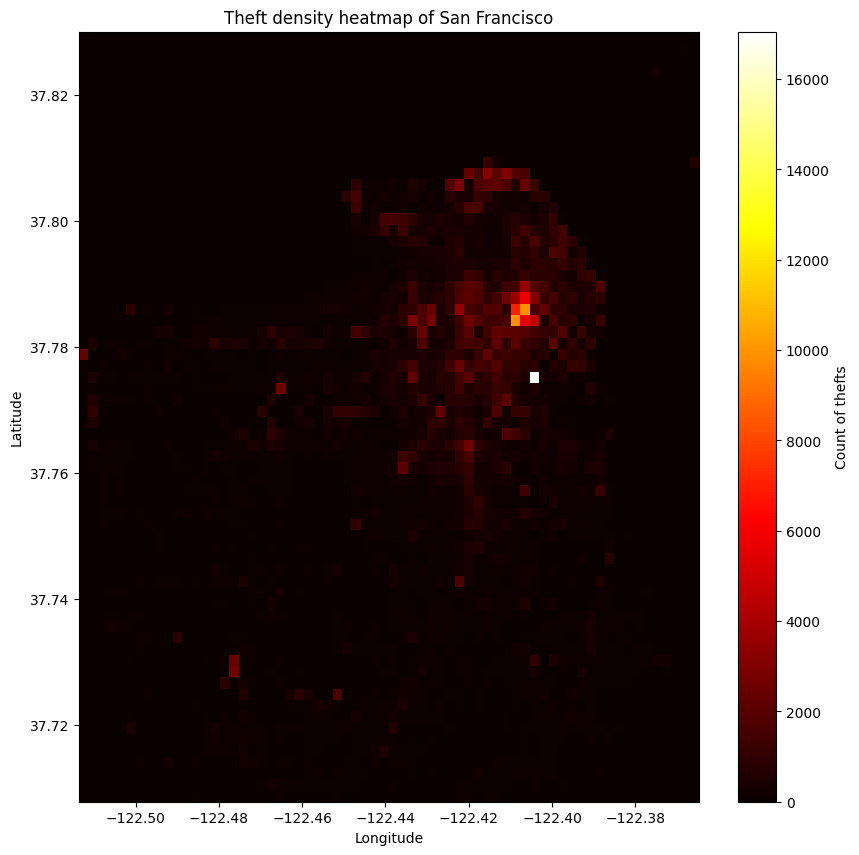

In [15]:
plt.figure(figsize=(10, 10))
plt.imshow(
    counts.T,
    cmap="hot",
    origin="lower",
    extent=[lon_min, lon_max, lat_min, lat_max],
    aspect="auto"
)
plt.colorbar(label="Count of thefts")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Theft density heatmap of San Francisco")
plt.show()

The above plot clearly show the same thing as we could see in the above log-log plot that a lot of the San Francisco map is dark and has little to no incidents of theft, while a few specific cells in the downtown area glow a lot. Another discovery we found from this plot is that it is very likely that since we have put a grid on San Francisco, then a lot of the cells with 0 incidents actually come from the sea around the peninsula, which gives a wrong over representation of 0 crime cells in the statistic. 

# 1.5: Regression and Correlation

This exercise compares the **weekly rhythms** of several crime types.

- Compute the number of incidents for each crime across the **168 hours of the week**.
- Create **pairwise scatterplots** comparing the hourly counts of each crime.
- Fit a **linear regression line** using the closed-form equations and compute \(R^2\).
- Identify which crime pair is **most correlated** and **least correlated**, and briefly interpret the result.

In [16]:
crimes = [
    "assault",
    "robbery",
    "vandalism",
    "motor vehicle theft",
]

In [ ]:
# Converting the hour of the week (0–167) from the timestamp
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df = df.dropna(subset=["datetime"]).copy()

df["hour_of_week"] = df["datetime"].dt.dayofweek * 24 + df["datetime"].dt.hour

df_focus = df[df["category"].isin(crimes)].copy()

In [18]:
hours = pd.Index(range(168), name="hour_of_week")

weekly_counts = (
    df_focus.groupby(["category", "hour_of_week"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=crimes)
    .reindex(columns=hours, fill_value=0)
)

In [ ]:
# Fit a linear regression line y = ax + b
def fit_line_closed_form(x, y):
    
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    N = len(x)

    x_mean = x.mean()
    y_mean = y.mean()

    num = (x * y).sum() - N * x_mean * y_mean
    den = (x * x).sum() - N * (x_mean ** 2)

    if den == 0:
        a = 0.0
        b = y_mean
    else:
        a = num / den
        b = y_mean - a * x_mean

    return a, b

# Compute the coefficient of determination (R^2) for the fitted regression line
def r2_manual(x, y, a, b):
    
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    y_hat = a * x + b
    ss_res = ((y - y_hat) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()

    if ss_tot == 0:
        return 0.0

    return 1 - (ss_res / ss_tot)

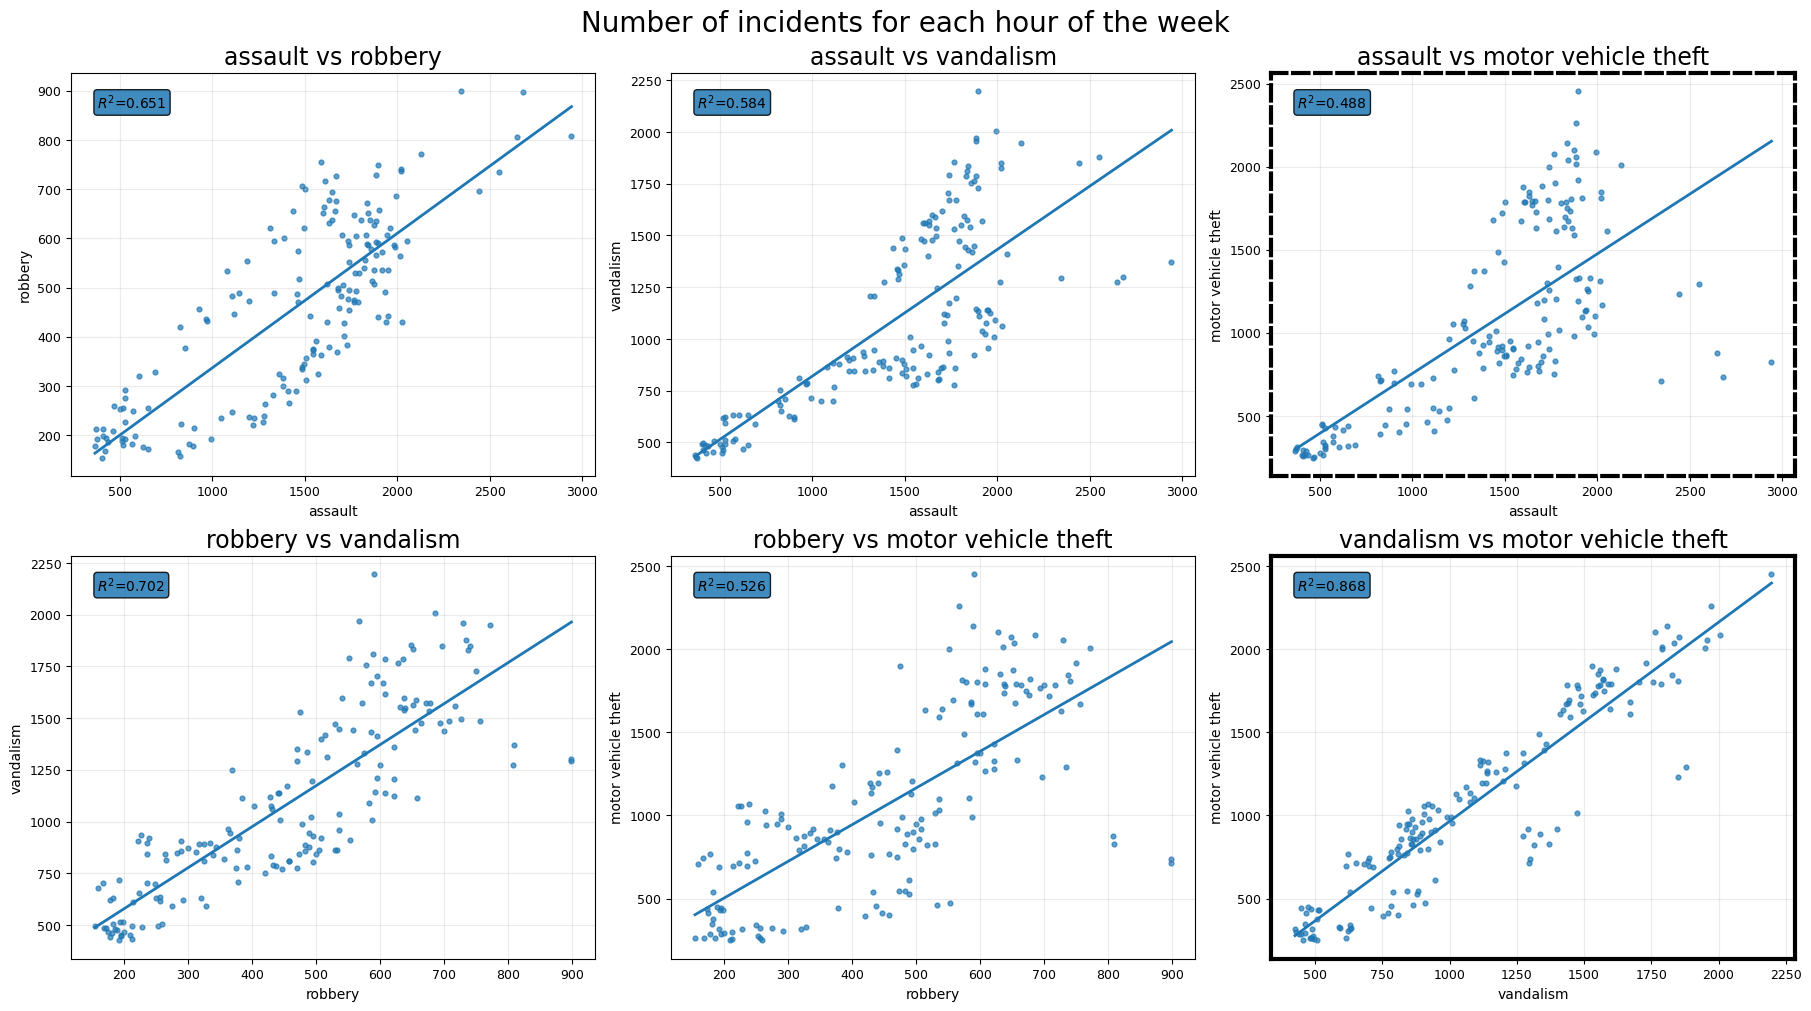

In [ ]:
# Generate all combinations and compute their regression
pairs = list(combinations(crimes, 2))
m = len(pairs)

ncols = 3
nrows = math.ceil(m / ncols)

results = {}
for c1, c2 in pairs:
    x = weekly_counts.loc[c1].values.astype(float)
    y = weekly_counts.loc[c2].values.astype(float)

    a, b = fit_line_closed_form(x, y)
    r2 = r2_manual(x, y, a, b)

    results[(c1, c2)] = (a, b, r2)

best_pair = max(results, key=lambda k: results[k][2])
worst_pair = min(results, key=lambda k: results[k][2])

# Create scatterplots and plot the regression line for each
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for idx, (c1, c2) in enumerate(pairs):
    ax = axes[idx]

    x = weekly_counts.loc[c1].values.astype(float)
    y = weekly_counts.loc[c2].values.astype(float)

    a, b, r2 = results[(c1, c2)]

    ax.scatter(x, y, s=12, alpha=0.7)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, a*xs + b, linewidth=2)

    ax.set_title(f"{c1} vs {c2}", fontsize=17)
    ax.set_xlabel(c1, fontsize=10)
    ax.set_ylabel(c2, fontsize=10)

    ax.text(0.05, 0.95, f"$R^2$={r2:.3f}",
            transform=ax.transAxes, ha="left", va="top",
            fontsize=10, bbox=dict(boxstyle="round,pad=0.25", alpha=0.85))

    ax.grid(True, alpha=0.25)
    ax.tick_params(labelsize=9)

    # Highlight the best/worst pairs
    if (c1, c2) == best_pair:
        for spine in ax.spines.values():
            spine.set_linewidth(3)

    if (c1, c2) == worst_pair:
        for spine in ax.spines.values():
            spine.set_linewidth(3)
            spine.set_linestyle("--")

for k in range(m, len(axes)):
    axes[k].axis("off")

plt.suptitle("Number of incidents for each hour of the week", fontsize=20)
plt.show()

From the scatterplot matrix and the computed $R^2$ values, the most correlated pair of crimes is vandalism and motor vehicle theft, with an $R^2$ = 0.847. This means there is a strong linear relationship for incidents between the these two crimes throughout the week. The points in the scatterplot are close to the regression line which means the two crimes have a similar weekly rhythm.

The least correlated pair is assault and motor vehicle theft, with an $R^2$ = 0.479. While there is still a positive relationship between them, there is heavy scatter around the regression line, indicating that their patterns throughout the week are less similar.

This makes sense because crimes like vandalism and motor vehicle theft have similarities in how they take place, such as occuring during nighttime hours or periods when fewer people are around. In contrast, assault is closer related to social interactions and crowded environments, which leads to a different weekly rhythm.

## Contributions

The work on this assignment was divided among the group members as follows:

- **Jacob Borregaard Eriksen (s181487)** – Exercises 1.1 and 1.4  
- **Rakibul Islam (s260126)** – Exercise 1.2  
- **Victor Philip Woergaard Eriksen (s234667)** – Exercises 1.3 and 1.5  

All members contributed to reviewing the final notebook and ensuring that the code runs correctly and produces the required outputs.